
# 🌱 Nivel FRECUENCIAS — Análisis de Sentimientos (versión corta y didáctica)

**Objetivo:** construir un pipeline **simple y completo** de NLP para clasificar opiniones (**positivo / negativo / neutro**) usando un **dataset CSV** y **TF‑IDF + Naive Bayes**.

**Flujo:** Carga de datos → Preprocesamiento → Vectorización (TF‑IDF) → Modelo → Métricas → Visualización → Predicción rápida


In [1]:

# 1️⃣ Librerías
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', 120)
print("Librerías cargadas ✅")


Librerías cargadas ✅



## 2️⃣ Carga de datos desde CSV (usaremos solo los **80 primeros** registros)
- Asegúrate de colocar el archivo `opiniones_big.csv` en el mismo directorio del notebook.
- Cambia los nombres de columna aquí si tu dataset usa otros (p. ej. `review`, `label`).

In [2]:

# Ruta del CSV (ajusta si fuera necesario)
CSV_PATH = "opiniones_big.csv"

df = pd.read_csv(CSV_PATH)

print("Columnas disponibles:", df.columns.tolist())

texto_cols =  ["texto"]
label_cols =  ["etiqueta"]

COL_TEXTO = texto_cols[0]
COL_LABEL = label_cols[0]

# Tomar solo 80 registros para evitar overfitting/accuracy=1.0
df = df[[COL_TEXTO, COL_LABEL]].dropna().head(80)
df[COL_TEXTO] = df[COL_TEXTO].astype(str)

print(f"Registros usados: {len(df)}")

# Distribución de clases
print( df['etiqueta'].value_counts())

df.head(5)


Columnas disponibles: ['texto', 'etiqueta']
Registros usados: 80
etiqueta
negativo    30
neutral     27
positivo    23
Name: count, dtype: int64


,texto,etiqueta
0,Mañana enviaré el informe final!,neutral
1,La reunión duró 30 minutos,neutral
2,Todo salió mejor de lo que esperaba.,positivo
3,El internet del hotel era lentísimo,negativo
4,"La verdad, El restaurante abre de lunes a viernes :)",neutral



## 3️⃣ Preprocesamiento textual (simple y directo)
- Para esta versión corta, confiamos en la normalización interna de `TfidfVectorizer` (minúsculas, tokenización básica).
- Si tu dataset viene con HTML o ruido, puedes limpiar adicionalmente aquí.


In [3]:

def preprocesar_minimo(texto: str) -> str:
    # Versión corta: solo strip. (TF-IDF ya hace lowercase por defecto)
    return str(texto).strip()

df["texto_proc"] = df[COL_TEXTO].apply(preprocesar_minimo)
df


,texto,etiqueta,texto_proc
0,Mañana enviaré el informe final!,neutral,Mañana enviaré el informe final!
1,La reunión duró 30 minutos,neutral,La reunión duró 30 minutos
2,Todo salió mejor de lo que esperaba.,positivo,Todo salió mejor de lo que esperaba.
3,El internet del hotel era lentísimo,negativo,El internet del hotel era lentísimo
4,"La verdad, El restaurante abre de lunes a viernes :)",neutral,"La verdad, El restaurante abre de lunes a viernes :)"
...,...,...,...
75,El envío fue rápido y bien embalado Excelente atención,positivo,El envío fue rápido y bien embalado Excelente atención
76,No cumplió con lo prometido :),negativo,No cumplió con lo prometido :)
77,Estoy esperando más información,neutral,Estoy esperando más información
78,"En serio, Los precios son abusivos Fatal",negativo,"En serio, Los precios son abusivos Fatal"


In [4]:
# Para enseñar la fase clásica de Preprocesamiento, Lematización con spaCy (es_core_news_sm)
'''
import spacy
from spacy.lang.es.stop_words import STOP_WORDS

# Cargar modelo en español
nlp = spacy.load("es_core_news_sm")

def preprocesar_completo(texto):
    doc = nlp(texto.lower())  # pasa a minúsculas
    tokens_limpios = [
        token.lemma_ for token in doc
        if token.is_alpha and token.text not in STOP_WORDS
    ]
    return " ".join(tokens_limpios)

df["texto_proc"] = df[COL_TEXTO].apply(preprocesar_completo)
df
'''

'\nimport spacy\nfrom spacy.lang.es.stop_words import STOP_WORDS\n\n# Cargar modelo en español\nnlp = spacy.load("es_core_news_sm")\n\ndef preprocesar_completo(texto):\n    doc = nlp(texto.lower())  # pasa a minúsculas\n    tokens_limpios = [\n        token.lemma_ for token in doc\n        if token.is_alpha and token.text not in STOP_WORDS\n    ]\n    return " ".join(tokens_limpios)\n\ndf["texto_proc"] = df[COL_TEXTO].apply(preprocesar_completo)\ndf\n'


## 4️⃣ Vectorización (TF‑IDF) y **5️⃣ Modelo** (Naive Bayes)
- Representamos cada opinión como un vector TF‑IDF.
- Entrenamos un clasificador `MultinomialNB`.
- Separación **train/test** con `stratify` para balance.


In [5]:

X = df["texto_proc"].values
y = df[COL_LABEL].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
# Usa n-gramas (1,2) para capturar “no fue”, “muy bueno”
#vectorizador = TfidfVectorizer(ngram_range=(1,2), min_df=2)  # min_df=2 reduce ruido

modelo = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=2000, ngram_range=(1,1), min_df=1)),      # Vectorización TF-IDF
    ("clf", MultinomialNB())           # Clasificador probabilístico
])

modelo.fit(X_train, y_train)
print("Modelo entrenado ✅")



Modelo entrenado ✅



## 6️⃣ Evaluación y métricas
Mostramos **accuracy**, **classification_report** (precisión, recall, F1) y **matriz de confusión**.


Accuracy: 0.917

Classification report:
              precision    recall  f1-score   support

    negativo       0.89      0.89      0.89         9
     neutral       1.00      1.00      1.00         8
    positivo       0.86      0.86      0.86         7

    accuracy                           0.92        24
   macro avg       0.92      0.92      0.92        24
weighted avg       0.92      0.92      0.92        24



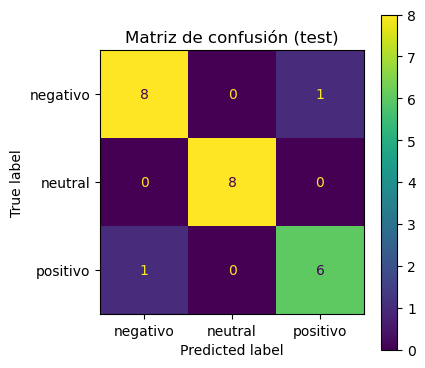

In [6]:

# Predicción en test
y_pred = modelo.predict(X_test)

# Métricas
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.3f}\n")

print("Classification report:")
print(classification_report(y_test, y_pred))

# Matriz de confusión (gráfico simple con matplotlib)
cm = confusion_matrix(y_test, y_pred, labels=np.unique(y))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y))
fig, ax = plt.subplots(figsize=(4.5, 4))
disp.plot(ax=ax)
plt.title("Matriz de confusión (test)")
plt.tight_layout()
plt.show()



## 7️⃣ Visualización final atractiva
Gráfico de barras con la **distribución de sentimientos** (verdaderos vs. predichos) en el conjunto de prueba.


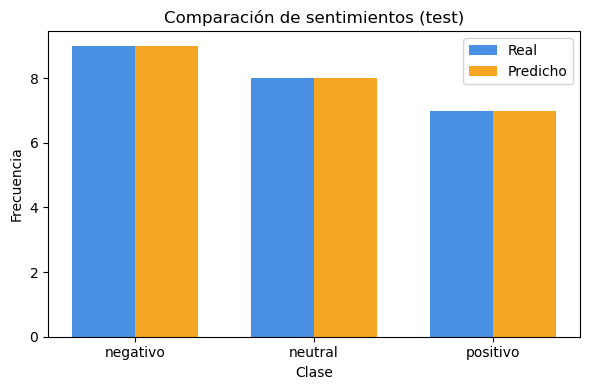

In [7]:
# Distribución real y predicha
vals_true = pd.Series(y_test).value_counts().sort_index()
vals_pred = pd.Series(y_pred).value_counts().reindex(vals_true.index).fillna(0)

clases = vals_true.index.astype(str)
x = np.arange(len(clases))
width = 0.35  # separación entre barras

fig, ax = plt.subplots(figsize=(6, 4))
b1 = ax.bar(x - width/2, vals_true.values, width, label="Real", color="#4a90e2")
b2 = ax.bar(x + width/2, vals_pred.values, width, label="Predicho", color="#f5a623")

ax.set_title("Comparación de sentimientos (test)")
ax.set_xlabel("Clase")
ax.set_ylabel("Frecuencia")
ax.set_xticks(x)
ax.set_xticklabels(clases)
ax.legend()
plt.tight_layout()
plt.show()



## 🧪 Predicción rápida (demo)
Cambia el texto y vuelve a ejecutar la celda para ver la predicción.


In [10]:

nuevo = "El producto llegó tarde y en mal estado."
pred = modelo.predict([nuevo])[0]
print("💬 Comentario:", nuevo)
print("🧠 Predicción:", pred.upper())


💬 Comentario: El producto llegó tarde y en mal estado.
🧠 Predicción: NEGATIVO
